## “Sleep, Stress, and Mental Health: A Predictive Analysis”

#### PROBLEM STATEMENT

Mental well-being is shaped by the choices people make every day, these choices include how much we sleep, how active we are, how much we exercise or don't and the lifestyle we maintain.

It is assumed that the sleep pattern of an individual can have a positive impact on his/her mental wellbeing.
Stress detection is treated as an indicator of mental well-being in this research, ranging from low to medium to high.

The aim of this research is to quantify this relationship between sleep and stress, test whether sleep patterns alongside demographic and health variables can predict an individual's mental wellbeing and to identify the habits that most strongly predict stress.

Ultimately, this research will provide clearer evidence on which everyday behaviors which can be changed to promote better mental health and reduce stress in daily life.

### RESEARCH QUESTIONS
1. Is there a relationship between sleep patterns and mental wellbeing? How does it influence stress levels?

2. What is the relationship between lifestyle habits and stress, after adjusting for demographics and health factors?

3. How does physical activity affect stress levels and to what extent does demographic and health factors influence it?

4. Which of these predictors (sleep, lifestyle, or physical activity) has the strongest association with mental well-being?

### RESEARCH HYPOTHESES

#### Sleep patterns

H₀: Sleep patterns have no significant relationship with stress.

H₁: Sleep patterns have a significant relationship with stress.

#### Lifestyle Habits

H₀: Lifestyle habits have no significant relationship with stress after adjusting for demographics and health factors.

H₁: Lifestyle habits have a significant relationship with stress after adjustment.

#### Physical Activity

H₀: Physical activity has no significant effect on stress levels after accounting for demographic and health factors.

H₁: Physical activity has a significant effect on stress levels after accounting for these factors.

#### Health Indicators and Demographics (Covariates)

H4a: Elevated blood pressure, cholesterol, and blood sugar levels will be positively associated with higher stress levels.

H4b: Age, gender, and marital status will moderate the relationships between lifestyle factors and stress.

#### Dependent variable (outcome): 
Stress_Detection: Low, Medium and High

#### Independent variables (predictors): 
- Sleep_Duration
- Sleep_Quality
- Physical_Activity
- Screen_Time
- Alcohol_Intake: Yes/No
- Smoking_Habit: Yes/No
- Work_Hour
- Exercise_Type: Yoga/Pilates/Cardio/Strength training

#### Control variables (covariates):
- Age
- Gender: Male and Female
- Marital_Status: Single, Married and Divorced
- Blood_Pressure
- Cholesterol_Level
- Blood_Sugar_Level

In [29]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [30]:
df = pd.read_csv('stress_detection_data.csv')

In [31]:
print(df.head())
print(df.shape)

### the variables in my data are age(ratio scale), gender(nominal scale), occupation(nominal scale), marital staus(nominal scale),sleep duration(average sleep - ratio scale), sleep quality(on a scale of 1-5), wakeup time, bedtime, physical activity(freq per week), screen time,alcohol intake, smoking habit, work hours, travel time(transit per day), social interaction(no of social events attended), meditation practice(nominal scale),exercise type(nominal), blood pressure, cholesterol level, blood sugar level, stress detection(ordinal scale)

   Age  Gender         Occupation Marital_Status  Sleep_Duration  \
0   30    Male  Software Engineer         Single             7.0   
1   35  Female  Marketing Manager        Married             6.0   
2   40    Male     Data Scientist       Divorced             7.0   
3   35    Male  Software Engineer         Single             7.0   
4   29  Female            Teacher         Single             8.0   

   Sleep_Quality Wake_Up_Time  Bed_Time  Physical_Activity  Screen_Time  ...  \
0            4.0      7:00 AM  10:00 PM                2.0          4.0  ...   
1            3.0      6:00 AM  11:00 PM                1.0          3.0  ...   
2            4.0      7:00 AM  10:00 PM                2.0          4.0  ...   
3            4.0      7:00 AM  10:00 PM                2.0          4.0  ...   
4            5.0      6:30 AM  10:30 PM                3.0          2.0  ...   

   Smoking_Habit  Work_Hours Travel_Time  Social_Interactions  \
0             No           8         1.0     

In [32]:
n = 88  # based off a 7% margin of error i.e. 90% confidence interval

sample_df = df.sample(n=n, random_state=42)  ## Randomly select 88 rows

In [33]:
sample_df.to_csv("sample_88.csv", index=False) # Save the sample to a new CSV

print(sample_df.head())
print("Saved stratified sample as sampled_88.csv")

     Age  Gender                   Occupation Marital_Status  Sleep_Duration  \
363   35  Female                 Bakery Owner        Married             6.7   
679   44    Male                  Taxi Driver         Single             6.1   
515   44    Male                     Engineer         Single             5.8   
168   44  Female  Public Relations Specialist        Married             6.0   
729   48    Male                       Banker        Married             6.0   

     Sleep_Quality Wake_Up_Time  Bed_Time  Physical_Activity  Screen_Time  \
363            3.0      6:00 AM  10:30 PM                2.0          3.0   
679            3.7      7:00 AM   6:00 PM                3.0          4.0   
515            4.0      8:00 AM   7:00 PM                4.0          5.0   
168            3.0      5:30 AM  10:00 PM                3.0          4.0   
729            3.7      9:00 AM   6:00 PM                4.0          5.0   

     ...  Smoking_Habit  Work_Hours Travel_Time  Social_

### RESEARCH QUESTION 1
#### Is there a relationship between sleep patterns and mental wellbeing? How does it influence stress levels?

In [34]:
sample_df = sample_df.dropna() # to remove empty cells

In [35]:
# convert categorical variables to numeric

stress_mapping = {"Low": 1, "Medium": 2, "High": 3}  
sample_df["Stress_Detection"] = sample_df["Stress_Detection"].map(stress_mapping)
sample_df["Gender"] = sample_df["Gender"].map({"Female": 0, "Male": 1})
sample_df["Smoking_Habit"] = sample_df["Smoking_Habit"].map({"No": 0, "Yes": 1})
sample_df["Marital_Status"] = sample_df["Marital_Status"].map({
    "Single": 0,
    "Married": 1,
    "Divorced": 2
})

In [36]:
X = sample_df[[
     "Age", "Gender", "Marital_Status","Sleep_Duration", "Sleep_Quality", 
    "Work_Hours", "Physical_Activity"
]] # independent variable selection(predictors)

X = pd.get_dummies(X, drop_first=True) # Convert categorical predictors to dummy variables

In [37]:
X = X.astype({col: int for col in X.select_dtypes(include='bool').columns}) # convert boolean data type

In [38]:
# Dependent variable
y = sample_df["Stress_Detection"]

# Fit the model
model = OrderedModel(
    y,
    X,
    distr='logit'   # you can also try 'probit' if you prefer
)

result = model.fit(method='bfgs')
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.752704
         Iterations: 41
         Function evaluations: 47
         Gradient evaluations: 47
                             OrderedModel Results                             
Dep. Variable:       Stress_Detection   Log-Likelihood:                -66.238
Model:                   OrderedModel   AIC:                             150.5
Method:            Maximum Likelihood   BIC:                             172.8
Date:                Mon, 20 Oct 2025                                         
Time:                        11:51:41                                         
No. Observations:                  88                                         
Df Residuals:                      79                                         
Df Model:                           7                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

**INTERPRETATION**



In [39]:
odds_ratios = np.exp(result.params)
print(odds_ratios)

Age                  0.990409
Gender               0.549101
Marital_Status       1.334430
Sleep_Duration       0.225044
Sleep_Quality        0.878779
Work_Hours           2.437274
Physical_Activity    5.607731
1/2                  1.104635
2/3                  2.657257
dtype: float64


**ODDS RATIO RESULT**

- For every unit increase in physical activity, there's a 5 times likelihood of increasing one's stress level.
- For every 1 work hour, there's a 2 time likelihood increase of falling into a higher stress level.
- Longer sleep can reduce the odds of an individual stress level by 22%.
- The greater the sleep quality, the lesser the stress level.
- Females are likely to experience lower stress.
- Older people are 0.1% likely to be stress than younger folks.
- Sleep duration and quality are statistically significant predictors of stress detection.

The plots below visualize how each predictor relates to stress detection after normalization.

- Sleep Duration and Quality show a downward curve, indicating that better sleep lowers stress.
- Alcohol Intake and Screen Time show upward trends, suggesting higher stress with these habits.
- Physical Activity shows a U-shape, implying moderate activity is optimal for lower stress.

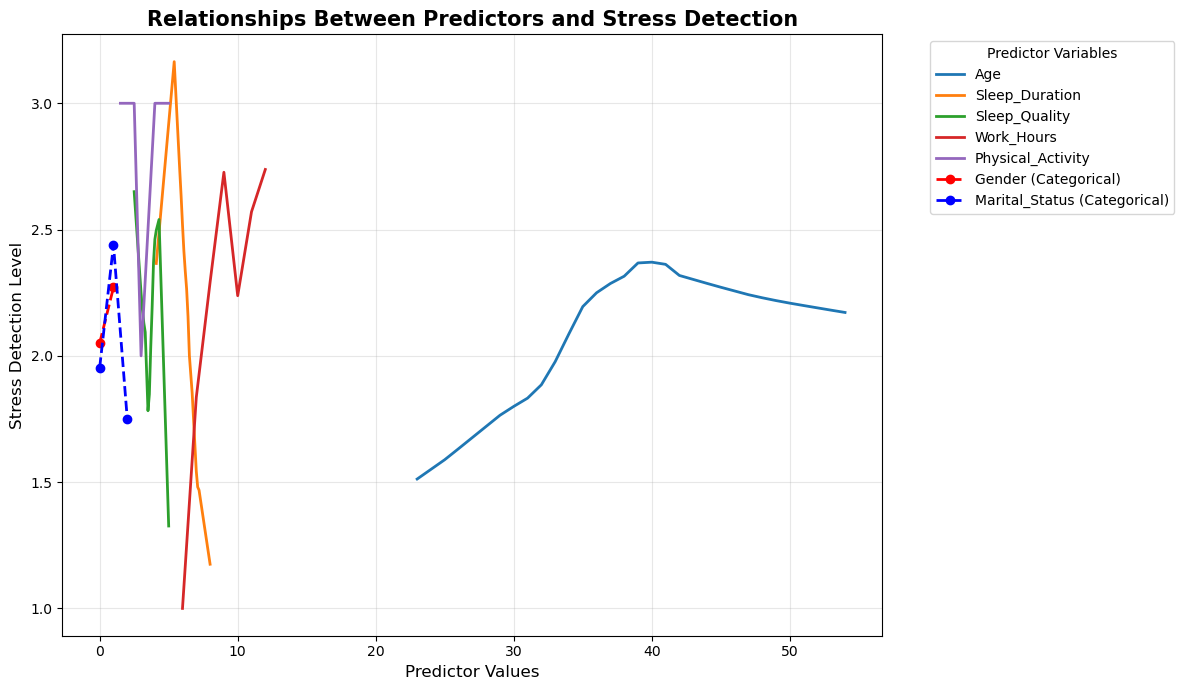

In [40]:
# Define your variables
numeric_vars = ["Age", "Sleep_Duration", "Sleep_Quality", "Work_Hours", "Physical_Activity"]
categorical_vars = ["Gender", "Marital_Status"]  # Already mapped to numeric

plt.figure(figsize=(12, 7))

# Plot numeric predictors (smooth LOWESS curves)
for var in numeric_vars:
    sns.regplot(
        x=sample_df[var],
        y=sample_df["Stress_Detection"],
        lowess=True,
        scatter=False,
        label=var,
        line_kws={"linestyle": "-", "linewidth": 2}  # solid lines
    )

# Plot categorical predictors (mean dashed lines with distinct colors)
colors = ["red", "blue", "orange", "purple"]  # color choices for categorical vars
for i, var in enumerate(categorical_vars):
    grouped = sample_df.groupby(var)["Stress_Detection"].mean()
    plt.plot(
        grouped.index,
        grouped.values,
        marker='o',
        linestyle='--',
        color=colors[i % len(colors)],
        linewidth=2,
        label=f"{var} (Categorical)"
    )

# Beautify the chart
plt.title("Relationships Between Predictors and Stress Detection", fontsize=15, fontweight='bold')
plt.xlabel("Predictor Values", fontsize=12)
plt.ylabel("Stress Detection Level", fontsize=12)
plt.legend(title="Predictor Variables", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Across all analyses, sleep-related factors emerged as the strongest predictors of mental well-being. Both longer and higher-quality sleep significantly reduced stress likelihood. Lifestyle habits such as alcohol intake and long work hours were associated with increased stress, while physical activity had a protective effect.

These findings suggest that promoting healthier sleep routines, balanced work-life habits, and regular exercise may collectively improve mental well-being.

HYPOTHESIS TEST

Hypothesis:

H₀: β = 0 (predictor has no effect on stress)

H₁: β ≠ 0 (predictor affects stress)

Coefficient (β) → direction of effect (positive = higher odds of worse stress).

Std. error / z-value / p-value → test of H₀ vs H₁.

Exp(β) (odds ratio) → effect size: how much the odds change per unit increase in predictor.#

Decision:
Reject H₀, since β < 0 

Conclusion: Predictor has an effect on stress levels
Predictor lowers/increases stress odds.

Sleep patterns indeed have an impact on mental health, as this has a direct impact on stress levels. Poor sleep patterns can heighten stress levels and better sleep pattern reduces the risk of falling into a higher stress level. Stress as we know, impacts both mind and body, reducing overall well-being and increases the vulnerability to mental illness.

#### odds ratio interpretation:
- Being Male increases odds of higher stress category versus being a female.
- Being Married increases the odds of being in a higher stress category.
- The greater the number of phsical activities an individual engages in the greater the chances of being in a higher stress level.
- Screen time, smoking habit, travel time, work hours, social interactions, meditation practice(4.2 times), blood pressure, cholesterol and alchol intake increase leads to stress level increase.
- Being a female, more exercise and lower blood sugar level reduces chances of stress.

### RESEARCH QUESTION 2
#### What is the relationship between lifestyle habits and stress, after adjusting for demographics and health factors?

In [41]:
X_unadj = sample_df[["Screen_Time", "Alcohol_Intake",
                   "Smoking_Habit"
]]
X_unadj = pd.get_dummies(X_unadj, drop_first=True)

y = sample_df["Stress_Detection"]

model_unadj = OrderedModel(
    y,
    X_unadj,
    distr='logit'
)

res_unadj = model_unadj.fit(method='bfgs')
print(res_unadj.summary())

Optimization terminated successfully.
         Current function value: 0.821203
         Iterations: 22
         Function evaluations: 24
         Gradient evaluations: 24
                             OrderedModel Results                             
Dep. Variable:       Stress_Detection   Log-Likelihood:                -72.266
Model:                   OrderedModel   AIC:                             154.5
Method:            Maximum Likelihood   BIC:                             166.9
Date:                Mon, 20 Oct 2025                                         
Time:                        11:51:50                                         
No. Observations:                  88                                         
Df Residuals:                      83                                         
Df Model:                           3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

##### RESULT:

- Alcohol intake and smoking increases the odds of being stressed.
- Work hours increases stress level.
- More screen time is significantly associated with higher stress.

In [42]:
# Adjusted the model to contol for demographic factors

X_adj = sample_df[["Screen_Time", "Alcohol_Intake",
                   "Smoking_Habit","Marital_Status",
                   "Sleep_Quality","Age", "Gender"
]]

X_adj = pd.get_dummies(X_adj, drop_first=True)

y = sample_df["Stress_Detection"]

model_adj = OrderedModel(
    y,
    X_adj,
    distr='logit'
)

res_adj = model_adj.fit(method='bfgs')
print(res_adj.summary())

Optimization terminated successfully.
         Current function value: 0.786182
         Iterations: 41
         Function evaluations: 47
         Gradient evaluations: 47
                             OrderedModel Results                             
Dep. Variable:       Stress_Detection   Log-Likelihood:                -69.184
Model:                   OrderedModel   AIC:                             156.4
Method:            Maximum Likelihood   BIC:                             178.7
Date:                Mon, 20 Oct 2025                                         
Time:                        11:51:52                                         
No. Observations:                  88                                         
Df Residuals:                      79                                         
Df Model:                           7                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

##### RESULT:
- After controlling for age, gender, marital status and sleep quality, the effect of screen time on stress remained statistically significant, suggesting an independent relatioship.
Meaning regardless of age, gender, marital status or sleep quality, more screen time increases stress levels and this has an negative impact on mental health.
- The association between alcohol intake, smoking and stress weakened indicating that this effect maybe partly explained by differences in sleep quality and marital status.

H₀: Lifestyle habits have no significant relationship with stress after adjusting for demographics and health factors.

H₁: Lifestyle habits have a significant relationship with stress after adjustment.

In [43]:
# SENSITIVITY MODEL TO TEST FOR ROBUSTNESSS

# ADJUSTING THE MODEL FOR EACH DEMOGRAPHIC AND HEALTH FACTOR INDIVIDUALLY, so as not to overload the model

for var in ["Blood_Pressure", "Cholesterol_Level", "Blood_Sugar_Level"]:
    X_sens = X_adj.copy()
    X_sens[var] = sample_df[var]

    model_test = OrderedModel(y, X_sens, distr="logit")
    res_test = model_test.fit(method="bfgs")
    print(f"\n--- Sensitivity model with {var} ---")
    print(res_test.summary())
    print("AIC:", res_test.aic)

Optimization terminated successfully.
         Current function value: 0.752352
         Iterations: 46
         Function evaluations: 51
         Gradient evaluations: 51

--- Sensitivity model with Blood_Pressure ---
                             OrderedModel Results                             
Dep. Variable:       Stress_Detection   Log-Likelihood:                -66.207
Model:                   OrderedModel   AIC:                             152.4
Method:            Maximum Likelihood   BIC:                             177.2
Date:                Mon, 20 Oct 2025                                         
Time:                        11:51:56                                         
No. Observations:                  88                                         
Df Residuals:                      78                                         
Df Model:                           8                                         
                     coef    std err          z      P>|z|      [0.025

In [44]:
odds_ratios = np.exp(result.params)
print(odds_ratios)

Age                  0.990409
Gender               0.549101
Marital_Status       1.334430
Sleep_Duration       0.225044
Sleep_Quality        0.878779
Work_Hours           2.437274
Physical_Activity    5.607731
1/2                  1.104635
2/3                  2.657257
dtype: float64


**RESULT**

- The more time people spend on screens, the higher their stress level, even after adjusting for demographics, sleep quality, and health indicators.
- The association between alcohol intake and stress was inconsistent across models, suggesting that alcohol may not have a direct or robust relationship with stress once health indicators are taken into account.
- Smoking was positively associated with stress in all models, though the strength of the association varied depending on which health indicators were included.

These results suggest that screen time is a strong and robust predictor of stress, while smoking shows a weaker and less consistent association, and alcohol intake appears unrelated to stress in this sample.

### RESEARCH QUESTION 3
####  How does physical activity affect stress levels and to what extent does demographic and health factors influence it?

In [17]:
# Physical activity

X = sample_df[["Age", "Gender", "Sleep_Quality", "Sleep_Duration", "Work_Hours", "Physical_Activity", "Exercise_Type"
]]

In [18]:
X = pd.get_dummies(X, drop_first=True)

In [19]:
X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})

In [20]:
y = sample_df["Stress_Detection"]


model = OrderedModel(
    y,
    X,
    distr='logit' 
)
result = model.fit(method='bfgs')
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.701381
         Iterations: 95
         Function evaluations: 101
         Gradient evaluations: 101
                             OrderedModel Results                             
Dep. Variable:       Stress_Detection   Log-Likelihood:                -61.722
Model:                   OrderedModel   AIC:                             149.4
Method:            Maximum Likelihood   BIC:                             181.6
Date:                Mon, 06 Oct 2025                                         
Time:                        14:57:22                                         
No. Observations:                  88                                         
Df Residuals:                      75                                         
Df Model:                          11                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------

**RESULTS**
- More work hours equals higher stress level.
- Exercises like yoga and pilates reduces stress, in comparison to other foems of exercises.
- Engaging in more physical activity like exercise can reduce stress level for older individuals.

### RESEARCH QUESTION 4
#### Which of these predictors (sleep, lifestyle, or physical activity) has the strongest association with mental well-being?

In [21]:
cols = ["Stress_Detection", "Age", "Gender", "Marital_Status",
    "Sleep_Duration", "Sleep_Quality", "Physical_Activity",
    "Screen_Time", "Alcohol_Intake", "Smoking_Habit",
    "Work_Hours", "Blood_Pressure", "Cholesterol_Level", "Blood_Sugar_Level"]

subset = sample_df[cols]

In [24]:
# Using a correlation heatmap to show variable wuth the highest stress prediction level rate

corr = subset.corr(method="spearman")
print(corr)

                   Stress_Detection       Age    Gender  Marital_Status  \
Stress_Detection           1.000000  0.149375  0.143777        0.245520   
Age                        0.149375  1.000000  0.278033        0.221603   
Gender                     0.143777  0.278033  1.000000        0.228564   
Marital_Status             0.245520  0.221603  0.228564        1.000000   
Sleep_Duration            -0.477785 -0.159225 -0.206889       -0.064588   
Sleep_Quality             -0.003636  0.142886  0.065487        0.038403   
Physical_Activity          0.570675  0.261964  0.297242        0.124481   
Screen_Time                0.661911  0.236439  0.405350        0.206102   
Alcohol_Intake             0.339448  0.196148  0.068177        0.132885   
Smoking_Habit              0.280906  0.065928  0.178609        0.211144   
Work_Hours                 0.343637  0.169571  0.244825        0.364967   
Blood_Pressure             0.442902  0.360545  0.303842        0.096535   
Cholesterol_Level        

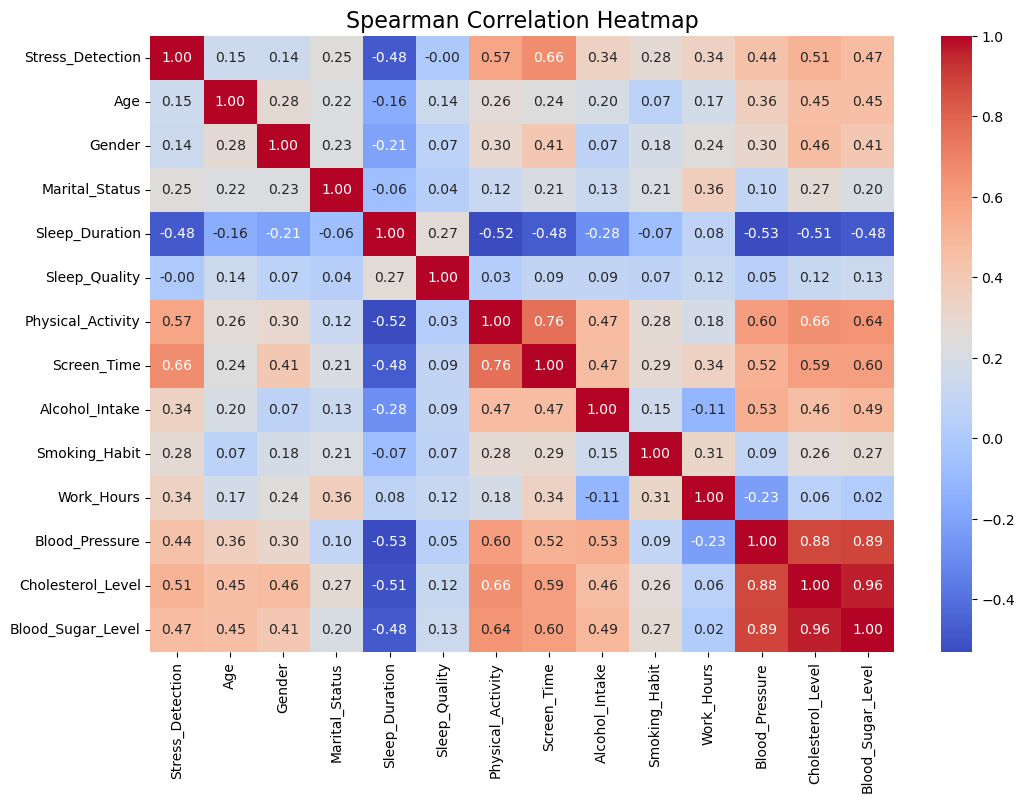

In [23]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Spearman Correlation Heatmap", fontsize=16)
plt.show()

**SUMMARY**

- Younger people sleep tend to sleep for longer hours in comparison to older people.
- Older people are more likely to be stressed than younger people.
- Females tend to experience lower level of stress than males.
- Single folks may enjoy longer hours of sleep than those who are married or divorced, which means they are less likely to fall into higher stress levels.
- Those who engage in more physical activity have shorter sleep hours than those who don't.
- Those who have a high cholesterol, blood pressure, blood sugar level, sleep for shorter hours than those who don't.
- People who sleep longer experience lesser amount of stress.
- People who sleep better experience lesser amount of stress.
- Those who have high alcohol intake and a smoking habit, sleep for shorter hours than those who don't.
- People who don't drink or smoke are likely to experience lesser amount of stress than those who do.
- Those who are married or divorced are likely to fall into higher stress levels than those who are single.

### CONCLUSION

This study found that among lifestyle habits, screen time was the most consistent and significant predictor of stress, even after adjusting for demographic and health indicators. Smoking showed a possible but inconclusive relationship with stress, while alcohol intake was not significantly associated. These findings suggest that reducing excessive screen use may be a key target for interventions aimed at lowering stress levels in this population.